In [13]:
import pandas as pd 

# 데이터 불러오기 
file_path = 'paysim.csv'
df = pd.read_csv(file_path)

# 처음 5줄 확인
display(df.head())

# 데이터 요약 정보 확인 
df.info()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [14]:
# 결측치 확인 (데이터 무결성 검증)
print("컬럼별 결측치 개수: ")
display(df.isnull().sum())

# 핵심 타겟 데이터 확인 (사기 거래(isFraud)건 수)
print("\n 정상 거래 vs 사기 거래 건수: ")
display(df['isFraud'].value_counts())

# 숫자형 데이터 요약 통계 보기 (평균 거래액, 최대 거래액 등)
display(df.describe())

컬럼별 결측치 개수: 


step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


 정상 거래 vs 사기 거래 건수: 


isFraud
0    6354407
1       8213
Name: count, dtype: int64

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [15]:
# 사기 거래(isFraud == 1) 데이터만 출력 
fraud_data = df[df['isFraud'] == 1]

print("사기 거래가 발생한 거래 유형(Type): ")
display(fraud_data['type'].value_counts())

print("\n 참고: 앱 전체 거래 유형 비율: ")
display(df['type'].value_counts())


사기 거래가 발생한 거래 유형(Type): 


type
CASH_OUT    4116
TRANSFER    4097
Name: count, dtype: int64


 참고: 앱 전체 거래 유형 비율: 


type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

In [16]:
# 정상(0)과 사기(1) 거래 그룹별로 평균 거래 금액(amount) 비교하기 
print(" 정상 vs 사기 거래 평균 금액 비교: ")
display(df.groupby('isFraud')['amount'].mean())


 정상 vs 사기 거래 평균 금액 비교: 


isFraud
0    1.781970e+05
1    1.467967e+06
Name: amount, dtype: float64

/var/folders/j3/7ttm5rwx6dz6b8md2n0f8ysr0000gn/T/ipykernel_26485/3894110100.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='isFraud', y='amount', data=mean_amount, palette=['#4C72B0', '#C44E52'])


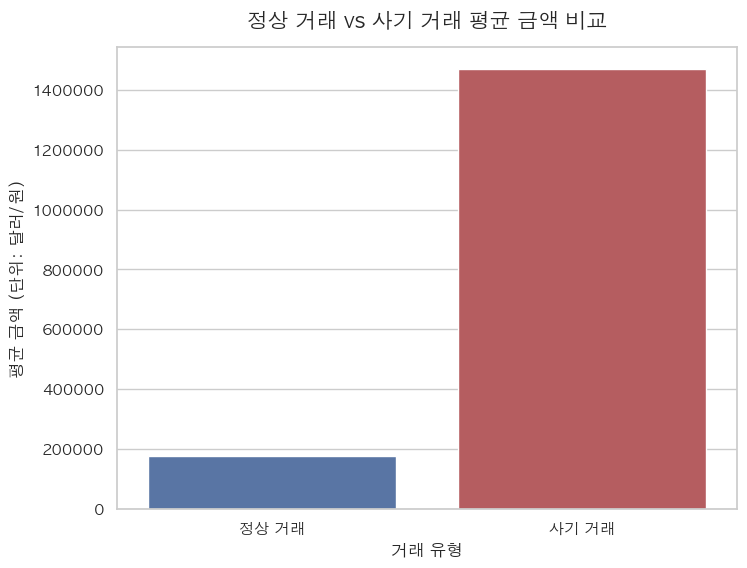

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False 

# 그래프 크기 및 배경 스타일 설정
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid", font='AppleGothic')

# 그룹별 평균 데이터 계산 및 라벨 변경
mean_amount = df.groupby('isFraud')['amount'].mean().reset_index()
mean_amount['isFraud'] = mean_amount['isFraud'].map({0: '정상 거래', 1: '사기 거래'})

# 막대그래프 그리고 (정상: 파란색, 사기: 빨간색)
ax = sns.barplot(x='isFraud', y='amount', data=mean_amount, palette=['#4C72B0', '#C44E52'])

# Y축의 지수 표기법(e+06)을 일반 숫자로 변경하여 가독성 높이기 
plt.ticklabel_format(style='plain', axis='y')

# 제목과 축 이름 설정 
plt.title('정상 거래 vs 사기 거래 평균 금액 비교', fontsize=15, pad=15, fontweight='bold')
plt.xlabel('거래 유형', fontsize=12)
plt.ylabel('평균 금액 (단위: 달러/원)', fontsize=12)

plt.show()

In [17]:
# 머신러닝 학습에 방해되는 텍스트 컬럼 (유저 ID 등) 제거 
# nameOrig, nameDest는 식별 번호라서 패턴 학습에 도움이 되지 않음 
df_ml = df.drop(['nameOrig', 'nameDest', 'isFlaggedFraud'], axis=1)

# 'type' 텍스트 컬럼을 숫자 (0과 1)로 변환 (원핫 인코딩, One-Hot Encoding)
# CASH_OUT, TRANSFER 등의 글자를 새로운 컬럼으로 쪼갬. 해당하면 1, 아니면 0으로 표시 
df_ml = pd.get_dummies(df_ml, columns=['type'])

# 전처리가 완료된 데이터 확인 
display(df_ml.head())
print(f"\n 전처리 후 데이터 크기: {df_ml.shape}")

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,170136.0,160296.36,0.0,0.0,0,False,False,False,True,False
1,1,1864.28,21249.0,19384.72,0.0,0.0,0,False,False,False,True,False
2,1,181.00,181.0,0.00,0.0,0.0,1,False,False,False,False,True
3,1,181.00,181.0,0.00,21182.0,0.0,1,False,True,False,False,False
4,1,11668.14,41554.0,29885.86,0.0,0.0,0,False,False,False,True,False



 전처리 후 데이터 크기: (6362620, 12)


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

# 문제지(X)와 정답지(y) 분리
# X: 사기 여부(isFraud)를 제외한 나머지 모든 데이터 (금액, 거래 유형, 잔액 등)
X = df_ml.drop('isFraud', axis=1)
# y: 우리가 맞혀야 할 정답 (사기 여부)
y = df_ml['isFraud']

# 학습용(80%)데이터와 테스트용(20%)데이터로 나누기 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 모델(의사결정나무) 생성 및 학습 
print("인공지능 모델이 패턴을 학습 중입니다... (약 10~30초 정도 소요됩니다)")
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# 학습이 끝난 인공지능에게 테스트용 데이터(X_test)를 주고 시험하기 
y_pred = model.predict(X_test)

# 인공지능이 예측한 답(y_pred)과 실제 정답(y_test)을 비교하여 출력 
print("\n학습 완료! 인공지능의 사기 탐지 결과: ")
print(classification_report(y_test, y_pred))


인공지능 모델이 패턴을 학습 중입니다... (약 10~30초 정도 소요됩니다)

학습 완료! 인공지능의 사기 탐지 결과: 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270904
           1       0.90      0.88      0.89      1620

    accuracy                           1.00   1272524
   macro avg       0.95      0.94      0.94   1272524
weighted avg       1.00      1.00      1.00   1272524

